
# Demo Notebook (Colab version): Multi-Scale Optimization Results

This notebook demonstrates:
- Loading the Part 4 report (`reports/multi_scale_optimization_report.json`) from **Google Drive**
- Building a trade-off table (size / accuracy / latency / memory / strategy)
- Plotting **Accuracy vs Size** and **Accuracy vs Latency**
- Quick inference on the selected Cloud (`.keras`) and Edge/Tiny (`.tflite`) models

> **Colab Steps (do this first):**
> 1. Upload my project folder to Drive, e.g. `MyDrive/mls_project` with the following subfolders:
>    - `reports/multi_scale_optimization_report.json`
>    - `cloud_optimized_models/*.keras`
>    - `edge_optimized_models/*_{drq,fp16,int8}.tflite`
> 2. Run the cell below to mount Drive and set `PROJECT_DIR` to the folder path.
> 3. Run all cells.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/mls_project"  #@param {type:"string"}

import os, glob, json
print("PROJECT_DIR =", PROJECT_DIR)

required = [
    os.path.join(PROJECT_DIR, "reports", "multi_scale_optimization_report.json"),
]
for p in required:
    print("CHECK:", p, "->", os.path.exists(p))


Mounted at /content/drive
PROJECT_DIR = /content/drive/MyDrive/mls_project
CHECK: /content/drive/MyDrive/mls_project/reports/multi_scale_optimization_report.json -> True


In [9]:
import os, time, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, tensorflow as tf

# Force CPU for reproducible latency
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
def _pin_cpu_only():
    try:
        tf.config.set_visible_devices([], "GPU")
        tf.config.set_visible_devices([], "TPU")
    except Exception:
        pass
_pin_cpu_only()


plt.rcParams['figure.figsize'] = (6,4)

def load_cifar10_test(num_samples=None):
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_test = x_test.astype("float32")/255.0
    y_test = y_test.reshape(-1)
    if num_samples is not None:
        x_test, y_test = x_test[:num_samples], y_test[:num_samples]
    return x_test, y_test

def _quantize_input_like(interpreter, x_batch):
    d = interpreter.get_input_details()[0]
    scale, zero = d["quantization"]
    dtype = d["dtype"]
    if scale == 0:
        return x_batch.astype(dtype)
    q = np.round(x_batch/scale + zero).astype(dtype)
    if np.issubdtype(dtype, np.integer):
        info = np.iinfo(dtype)
        q = np.clip(q, info.min, info.max)
    return q

def evaluate_keras_latency_accuracy(model, x, y, warmup=10, runs=50, batch_size=1):
    # accuracy
    y_prob = model.predict(x, batch_size=64, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = float(np.mean(y_pred == y))

    # single-sample latency
    sample = x[:batch_size]
    for _ in range(warmup):
        _ = model.predict(sample, batch_size=batch_size, verbose=0)
    t0 = time.perf_counter()
    for _ in range(runs):
        _ = model.predict(sample, batch_size=batch_size, verbose=0)
    t1 = time.perf_counter()
    lat_ms = (t1 - t0)/runs*1000.0
    return acc, lat_ms

def evaluate_tflite_latency_accuracy(tflite_path, x, y, warmup=20, runs=50, batch_size=1):
    interpreter = tf.lite.Interpreter(model_path=tflite_path, num_threads=1)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # latency
    xb = x[:batch_size]
    inp = _quantize_input_like(interpreter, xb)
    for _ in range(warmup):
        interpreter.set_tensor(input_details[0]['index'], inp)
        interpreter.invoke()
    t0 = time.perf_counter()
    for _ in range(runs):
        interpreter.set_tensor(input_details[0]['index'], inp)
        interpreter.invoke()
    t1 = time.perf_counter()
    lat_ms = (t1 - t0)/runs*1000.0

    # accuracy (first 2000)
    N = min(2000, x.shape[0])
    correct = 0
    for i in range(N):
        xi = _quantize_input_like(interpreter, x[i:i+1])
        interpreter.set_tensor(input_details[0]['index'], xi)
        interpreter.invoke()
        logits = interpreter.get_tensor(output_details[0]['index'])
        if int(np.argmax(logits, axis=1)[0]) == int(y[i]):
            correct += 1
    acc = correct/N
    return float(acc), float(lat_ms)


In [3]:

#@title Load Part 4 report and build the trade-off table
REPORT = os.path.join(PROJECT_DIR, "reports", "multi_scale_optimization_report.json")
with open(REPORT, "r") as f:
    report = json.load(f)

res = report["optimization_results"]
rows = []
for target, d in res.items():
    rows.append({
        "Target": target,
        "Strategy": d["optimization_strategy"],
        "Model Path": d["model_path"],
        "Model Size (MB)": float(d["model_size_mb"]),
        "Accuracy": float(d["accuracy"]),
        "Latency (ms)": float(d["estimated_latency_ms"]),
        "Memory (MB)": float(d["memory_usage_mb"]),
    })
df = pd.DataFrame(rows)
df.sort_values("Target")
df


,Target,Strategy,Model Path,Model Size (MB),Accuracy,Latency (ms),Memory (MB)
0,cloud_server,cloud:mp_cnn_ep15.keras,cloud_optimized_models/mp_cnn_ep15.keras,6.602265,0.7706,27.807643,13.216818
1,edge_device,tflite:drq,edge_optimized_models/depthwise_w0_75_d1_0_drq...,0.059056,0.6250,0.108184,1.059056
2,microcontroller,tflite:int8_prebuilt,edge_optimized_models/depthwise_w0_75_d1_0_int...,0.062144,0.6150,0.066351,1.065226


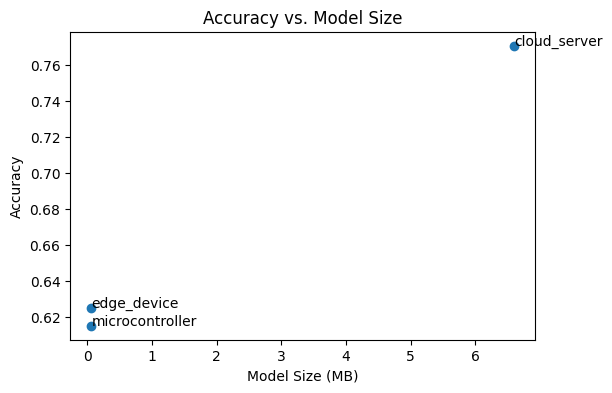

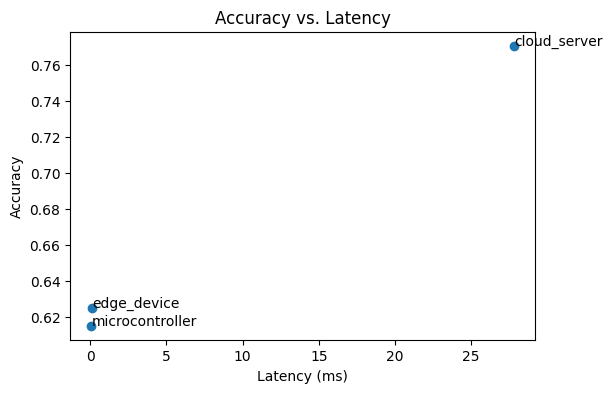

Saved charts to: /content/drive/MyDrive/mls_project/charts


In [5]:

#@title Charts: Accuracy vs Size, Accuracy vs Latency (saved to Drive)
CHART_DIR = os.path.join(PROJECT_DIR, "charts")
os.makedirs(CHART_DIR, exist_ok=True)

# Accuracy vs Size
plt.figure()
plt.scatter(df["Model Size (MB)"], df["Accuracy"])
for _, r in df.iterrows():
    plt.text(r["Model Size (MB)"], r["Accuracy"], r["Target"])
plt.xlabel("Model Size (MB)"); plt.ylabel("Accuracy"); plt.title("Accuracy vs. Model Size")
plt.savefig(os.path.join(CHART_DIR, "accuracy_vs_size.png"), bbox_inches="tight")
plt.show()

# Accuracy vs Latency
plt.figure()
plt.scatter(df["Latency (ms)"], df["Accuracy"])
for _, r in df.iterrows():
    plt.text(r["Latency (ms)"], r["Accuracy"], r["Target"])
plt.xlabel("Latency (ms)"); plt.ylabel("Accuracy"); plt.title("Accuracy vs. Latency")
plt.savefig(os.path.join(CHART_DIR, "accuracy_vs_latency.png"), bbox_inches="tight")
plt.show()

print("Saved charts to:", CHART_DIR)


In [6]:

#@title Quick inference for Cloud (.keras)
x_test, y_test = load_cifar10_test(5000)

cloud_path = res["cloud_server"]["model_path"]
if not os.path.isabs(cloud_path):
    cloud_path = os.path.join(PROJECT_DIR, cloud_path)
print("Cloud model:", cloud_path)

try:
    cloud_model = tf.keras.models.load_model(cloud_path)
    acc, lat = evaluate_keras_latency_accuracy(cloud_model, x_test, y_test, runs=50)
    print(f"Cloud ACC={acc:.4f}  LAT(ms)={lat:.4f}")
except Exception as e:
    import traceback; traceback.print_exc()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Cloud model: /content/drive/MyDrive/mls_project/cloud_optimized_models/mp_cnn_ep15.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 46 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Cloud ACC=0.7706  LAT(ms)=92.3302


In [7]:

#@title Quick inference for Edge (.tflite)
edge_path = res["edge_device"]["model_path"]
if not os.path.isabs(edge_path):
    edge_path = os.path.join(PROJECT_DIR, edge_path)
print("Edge model:", edge_path)

try:
    a, l = evaluate_tflite_latency_accuracy(edge_path, x_test, y_test, runs=50)
    print(f"Edge ACC={a:.4f}  LAT(ms)={l:.4f}")
except Exception as e:
    import traceback; traceback.print_exc()


Edge model: /content/drive/MyDrive/mls_project/edge_optimized_models/depthwise_w0_75_d1_0_drq.tflite


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Edge ACC=0.6130  LAT(ms)=0.2243


In [8]:

#@title Quick inference for Tiny (.tflite)
tiny_path = res["microcontroller"]["model_path"]
if not os.path.isabs(tiny_path):
    tiny_path = os.path.join(PROJECT_DIR, tiny_path)
print("Tiny model:", tiny_path)

try:
    a, l = evaluate_tflite_latency_accuracy(tiny_path, x_test, y_test, runs=50)
    print(f"Tiny ACC={a:.4f}  LAT(ms)={l:.4f}")
except Exception as e:
    import traceback; traceback.print_exc()


Tiny model: /content/drive/MyDrive/mls_project/edge_optimized_models/depthwise_w0_75_d1_0_int8.tflite
Tiny ACC=0.6150  LAT(ms)=0.5346
